# Identifying errors in simulation ouput

This notebook uses the litter model as an example to demonstrate the basic process of
tracking down bugs simulation output data.

In [1]:
%%bash
# Install the example data directory from the Virtual Ecosystem package
# This is currently using my desktop, but this should change in future (probably)
ve_run --install-example /Users/jc2017/Desktop

# Rename config (and out) to original_config to make it clearer that it is unchanged
mv /Users/jc2017/Desktop/ve_example/config /Users/jc2017/Desktop/ve_example/original_config
mv /Users/jc2017/Desktop/ve_example/out /Users/jc2017/Desktop/ve_example/original_out

Example directory created at:
/Users/jc2017/Desktop/ve_example


## Setting up models to run in static mode

In order to rule out impacts of other models, they should be set to run in static mode.
Additionally, stochastic tree death in the plants model needs to be turned off as this
generates unpredictable differences between simulations.

The steps below modify the initial configuration so that all non-litter models are
static and so that probability of random tree mortality is zero.

In [2]:
import tomllib

import tomli_w

with open("/Users/jc2017/Desktop/ve_example/original_config/ve_run.toml", "rb") as f:
    general_config = tomllib.load(f)

general_config["abiotic_simple"]["static"] = True
general_config["hydrology"]["static"] = True
general_config["soil"]["static"] = True
general_config["animal"]["static"] = True

with open("/Users/jc2017/Desktop/ve_example/original_config/ve_run.toml", "wb") as f:
    tomli_w.dump(general_config, f)

In [3]:
with open(
    "/Users/jc2017/Desktop/ve_example/original_config/plant_config.toml", "rb"
) as f:
    plant_config = tomllib.load(f)

plant_config["plants"]["static"] = True
plant_config["plants"].setdefault("constants", {})
plant_config["plants"]["constants"].setdefault("PlantsConsts", {})
plant_config["plants"]["constants"]["PlantsConsts"][
    "per_stem_annual_mortality_probability"
] = 0.0

with open(
    "/Users/jc2017/Desktop/ve_example/original_config/plant_config.toml", "wb"
) as f:
    tomli_w.dump(plant_config, f)

## Altering configuration to run simulation with a changed parameter

We now want to double the decay rate of one of the pools (above ground metabolic) to see
how this changes the simulation results. This is achieved by duplicating the
configuration, modifying the configuration so that the relevant litter decay constant is
doubled, and then running the simulation both for the orgininal configuration and for
the altered simulation.

In [4]:
%%bash
cp -r /Users/jc2017/Desktop/ve_example/original_config /Users/jc2017/Desktop/ve_example/increased_meta_decay_config

mkdir /Users/jc2017/Desktop/ve_example/increased_meta_decay_out

In [5]:
with open(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_config/ve_run.toml", "rb"
) as f:
    general_config = tomllib.load(f)

general_config["litter"].setdefault("constants", {})
general_config["litter"]["constants"].setdefault("LitterConsts", {})
general_config["litter"]["constants"]["LitterConsts"][
    "litter_decay_constant_metabolic_above"
] = 0.16

with open(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_config/ve_run.toml", "wb"
) as f:
    tomli_w.dump(general_config, f)

In [6]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/original_config \
    --outpath /Users/jc2017/Desktop/ve_example/original_out \
    --logfile /Users/jc2017/Desktop/ve_example/original_out/original.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/original_out/original.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/original_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
  0%|          | 0/24 [00:00<?, ?it/s]

pyrealm/plants_model.py:933: RuntimeWarning: invalid value encountered in divide


100%|██████████| 24/24 [00:02<00:00,  9.09it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


In [7]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/increased_meta_decay_config \
    --outpath /Users/jc2017/Desktop/ve_example/increased_meta_decay_out \
    --logfile /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/increased_decay.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/increased_decay.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/increased_meta_decay_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
  0%|          | 0/24 [00:00<?, ?it/s]

pyrealm/plants_model.py:933: RuntimeWarning: invalid value encountered in divide


100%|██████████| 24/24 [00:02<00:00,  9.05it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


First check the total mineralisation of carbon. Clearly something very wrong here as
getting negative values.

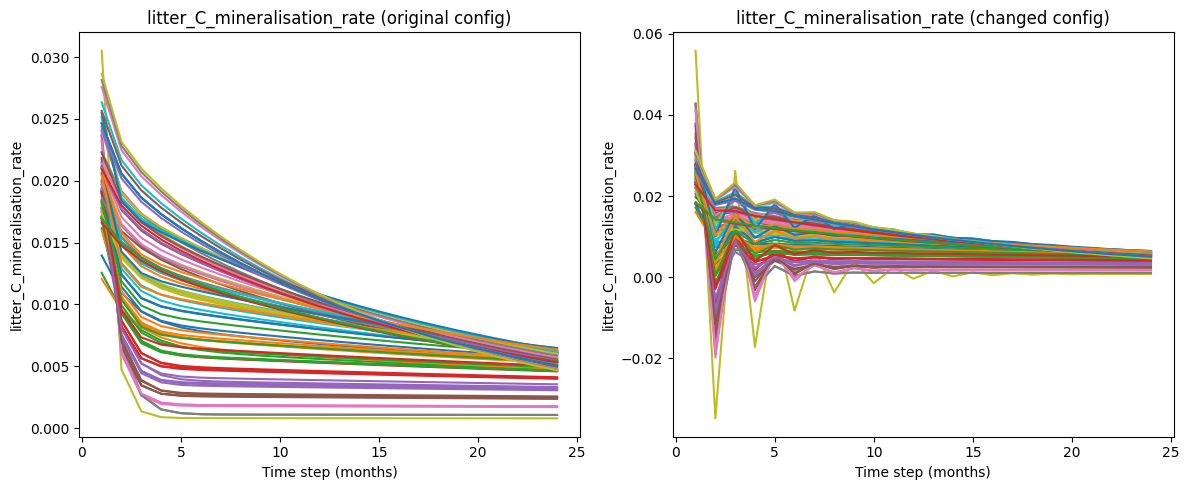

In [9]:
import matplotlib.pyplot as plt
import xarray

original = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/original_out/all_continuous_data.nc"
)
increased_above_meta_decay = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/increased_meta_decay_out/all_continuous_data.nc"
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_C_mineralisation_rate"])
ax1.set_title("litter_C_mineralisation_rate (original config)")
ax1.set_ylabel("litter_C_mineralisation_rate")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["litter_C_mineralisation_rate"],
)
ax2.set_title("litter_C_mineralisation_rate (changed config)")
ax2.set_ylabel("litter_C_mineralisation_rate")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

The problem also extends to the carbon nitrogen ratios of the above metabolic pools
which also oscillate wildly. Again there are imporssible negative values

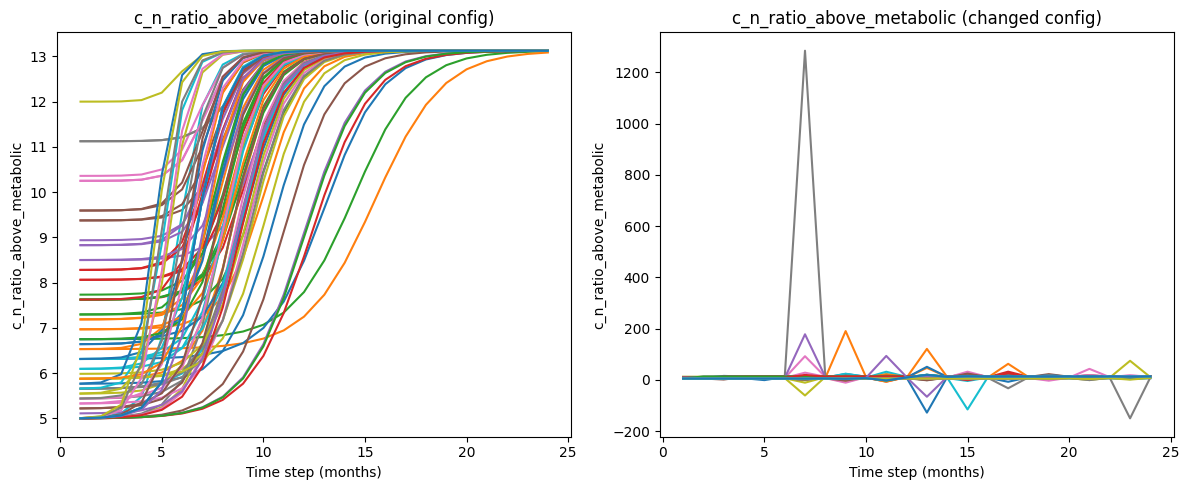

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["c_n_ratio_above_metabolic"])
ax1.set_title("c_n_ratio_above_metabolic (original config)")
ax1.set_ylabel("c_n_ratio_above_metabolic")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["c_n_ratio_above_metabolic"],
)
ax2.set_title("c_n_ratio_above_metabolic (changed config)")
ax2.set_ylabel("c_n_ratio_above_metabolic")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

The above ground metabolic litter pool decays to a very low value in the first case, in
the second increased decay case it decays below zero. This completely breaks the model
logic and everything down stream of this is likely to be nonsense.

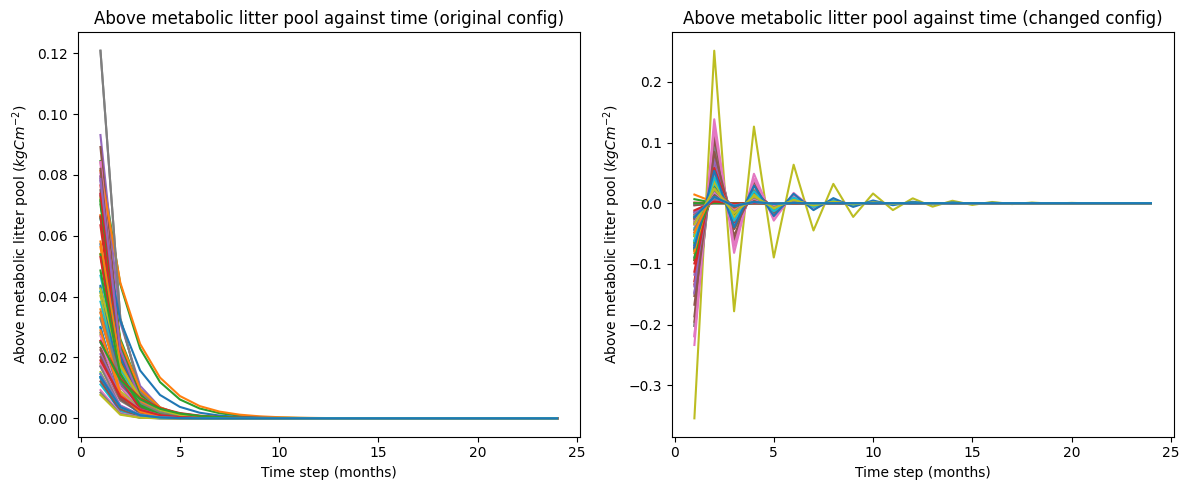

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_pool_above_metabolic"])
ax1.set_title("Above metabolic litter pool against time (original config)")
ax1.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_meta_decay["time_index"],
    increased_above_meta_decay["litter_pool_above_metabolic"],
)
ax2.set_title("Above metabolic litter pool against time (changed config)")
ax2.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

### Does the same happen for the above ground structural litter pool

We will now test whether the same problem emerges for the above ground structural litter
pool, by repeating the process above and checking if any pools go negative.

In [12]:
%%bash
cp -r /Users/jc2017/Desktop/ve_example/original_config /Users/jc2017/Desktop/ve_example/increased_struct_decay_config

mkdir /Users/jc2017/Desktop/ve_example/increased_struct_decay_out

In [13]:
with open(
    "/Users/jc2017/Desktop/ve_example/increased_struct_decay_config/ve_run.toml", "rb"
) as f:
    general_config = tomllib.load(f)

general_config["litter"].setdefault("constants", {})
general_config["litter"]["constants"].setdefault("LitterConsts", {})
general_config["litter"]["constants"]["LitterConsts"][
    "litter_decay_constant_structural_above"
] = 0.0434

with open(
    "/Users/jc2017/Desktop/ve_example/increased_struct_decay_config/ve_run.toml", "wb"
) as f:
    tomli_w.dump(general_config, f)

In [14]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/increased_struct_decay_config \
    --outpath /Users/jc2017/Desktop/ve_example/increased_struct_decay_out \
    --logfile /Users/jc2017/Desktop/ve_example/increased_struct_decay_out/increased_decay.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/increased_struct_decay_out/increased_decay.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/increased_struct_decay_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
  0%|          | 0/24 [00:00<?, ?it/s]

pyrealm/plants_model.py:933: RuntimeWarning: invalid value encountered in divide


100%|██████████| 24/24 [00:02<00:00,  9.01it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


For the above ground structural pools the graph is completely normal. Key thing to note
is that most pools remain above zero, in contrast to the metabolic case where they can
get close to zero within the first month

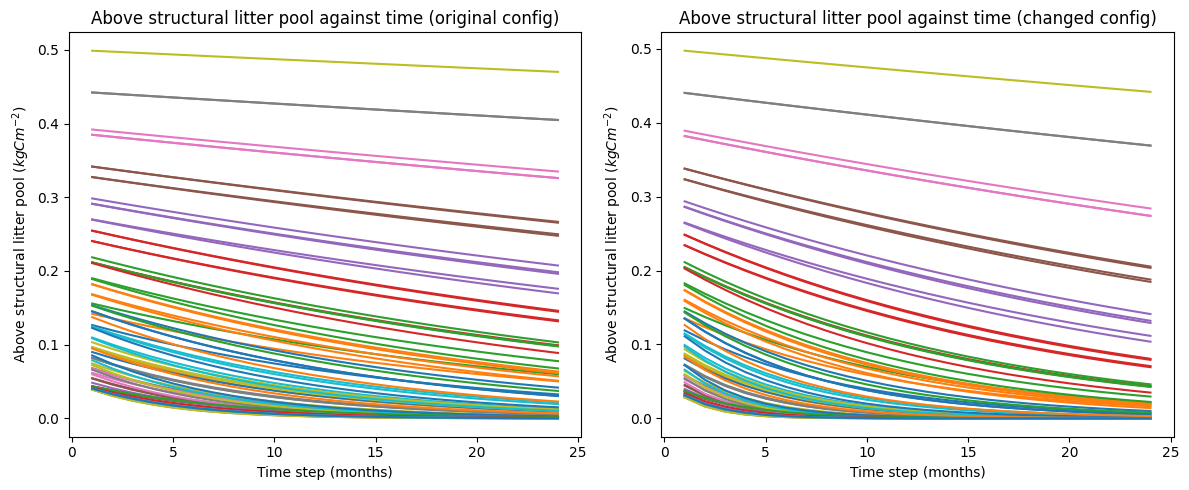

In [ ]:
increased_above_struct_decay = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/increased_struct_decay_out/all_continuous_data.nc"
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_pool_above_structural"])
ax1.set_title("Above structural litter pool against time (original config)")
ax1.set_ylabel("Above structural litter pool ($kg C m^{-2}$)")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_above_struct_decay["time_index"],
    increased_above_struct_decay["litter_pool_above_structural"],
)
ax2.set_title("Above structural litter pool against time (changed config)")
ax2.set_ylabel("Above structural litter pool ($kg C m^{-2}$)")
ax2.set_xlabel("Time step (months)")

plt.tight_layout()

The model currently updates based on an extremely simple numerical integration scheme,
with the new pool size being found using

$$P_f = P_i + I - d \Delta t,$$

where $P_i$ is the initial pool size, $I$ is the total input to the pool over the time
step, $d$ is the decay rate, and $\Delta t$ is the time step.

This is only a good approxmation if the decay rate is not changing rapidly. This is
definetely not for the metabolic pools in the increased decay scenario as the pool sizes
rapidly decrease meaning that decay rate has to decrease (but can't as it is assumed to
be fixed for the time step)

To test this hypothesis, we will run another increasd metabolic pool scenario but this
time using a weekly rather than monthly time step.

In [16]:
%%bash
cp -r /Users/jc2017/Desktop/ve_example/original_config /Users/jc2017/Desktop/ve_example/increased_decay_weeks_config

mkdir /Users/jc2017/Desktop/ve_example/increased_decay_weeks_out

In [17]:
with open(
    "/Users/jc2017/Desktop/ve_example/increased_decay_weeks_config/ve_run.toml", "rb"
) as f:
    general_config = tomllib.load(f)

general_config["litter"].setdefault("constants", {})
general_config["litter"]["constants"].setdefault("LitterConsts", {})
general_config["litter"]["constants"]["LitterConsts"][
    "litter_decay_constant_metabolic_above"
] = 0.16

general_config["core"].setdefault("timing", {})
general_config["core"]["timing"]["update_interval"] = "1 week"

with open(
    "/Users/jc2017/Desktop/ve_example/increased_decay_weeks_config/ve_run.toml", "wb"
) as f:
    tomli_w.dump(general_config, f)

In [18]:
%%bash
ve_run /Users/jc2017/Desktop/ve_example/increased_decay_weeks_config \
    --outpath /Users/jc2017/Desktop/ve_example/increased_decay_weeks_out \
    --logfile /Users/jc2017/Desktop/ve_example/increased_decay_weeks_out/increased_decay.log

Starting Virtual Ecosystem simulation.
Logging to: /Users/jc2017/Desktop/ve_example/increased_decay_weeks_out/increased_decay.log
* Loading configuration
* Saved compiled configuration: /Users/jc2017/Desktop/ve_example/increased_decay_weeks_out/ve_full_model_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: soil, hydrology, abiotic_simple, animal, litter, plants
* Saved model initial state
* Starting simulation
  0%|          | 0/105 [00:00<?, ?it/s]

pyrealm/plants_model.py:933: RuntimeWarning: invalid value encountered in divide


100%|██████████| 105/105 [00:07<00:00, 14.65it/s]
* Simulation completed
* Merged time series data
* Saved final model state
Virtual Ecosystem run complete.


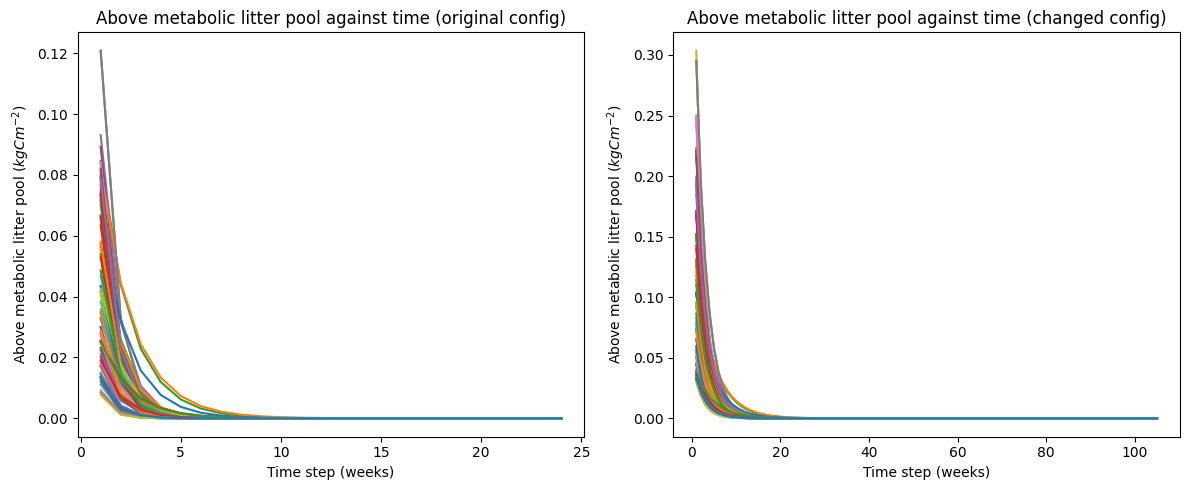

In [ ]:
increased_decay_weeks = xarray.load_dataset(
    "/Users/jc2017/Desktop/ve_example/increased_decay_weeks_out/all_continuous_data.nc"
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_pool_above_metabolic"])
ax1.set_title("Above metabolic litter pool against time (original config)")
ax1.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_decay_weeks["time_index"],
    increased_decay_weeks["litter_pool_above_metabolic"],
)
ax2.set_title("Above metabolic litter pool against time (changed config)")
ax2.set_ylabel("Above metabolic litter pool ($kg C m^{-2}$)")
ax2.set_xlabel("Time step (weeks)")

plt.tight_layout()

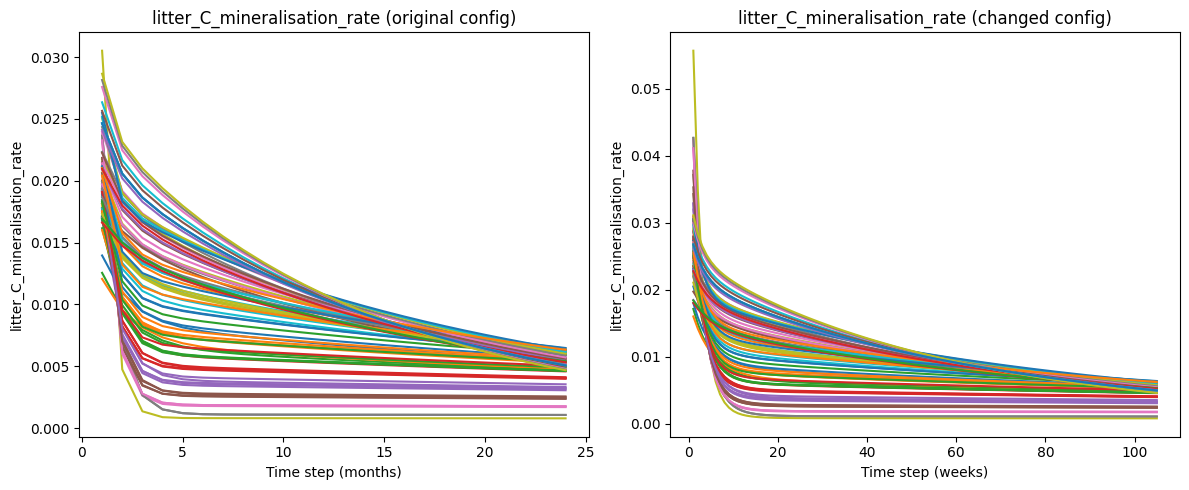

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.plot(original["time_index"], original["litter_C_mineralisation_rate"])
ax1.set_title("litter_C_mineralisation_rate (original config)")
ax1.set_ylabel("litter_C_mineralisation_rate")
ax1.set_xlabel("Time step (months)")

ax2.plot(
    increased_decay_weeks["time_index"],
    increased_decay_weeks["litter_C_mineralisation_rate"],
)
ax2.set_title("litter_C_mineralisation_rate (changed config)")
ax2.set_ylabel("litter_C_mineralisation_rate")
ax2.set_xlabel("Time step (weeks)")

plt.tight_layout()